In [ ]:
import nltk  # Biblioteca usada para o processamento de linguagem natural
import spacy  # Biblioteca para processamento de linguagem natural e análise de texto
import pandas as pd  # Biblioteca para manipulação e análise de dados estruturados
import seaborn as sns
import matplotlib.pyplot as plt  # Biblioteca para criação de gráficos e visualizações
from wordcloud import WordCloud  # Biblioteca para gerar nuvens de palavras a partir de textos
from collections import Counter  # Biblioteca para contagem de elementos em iteráveis, útil para análise de frequência
from nltk.corpus import stopwords  # Módulo do NLTK que fornece uma lista de palavras comuns a serem ignoradas (stop words)
import re  # Biblioteca para manipulação e busca de padrões em strings usando expressões regulares
import unicodedata
from pprint import pprint

In [ ]:
# Download necessário para a NLTK
nltk.download('stopwords')  # Baixa a lista de stop words (palavras comuns) para uso no processamento de texto
nltk.download('punkt')  # Baixa o tokenizer Punkt, necessário para a tokenização de frases

# Carregar o modelo de português para o spaCy
!python -m spacy download pt_core_news_sm

[nltk_data] Downloading package stopwords to /home/marcos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/marcos/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 12.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


In [ ]:
data = pd.read_csv('../concatenacao/dataset_concat2.0_tratado_Gustavo_e_Ivan.csv', sep=';')

/tmp/ipykernel_2015/348069457.py:1: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../concatenacao/dataset_concat2.0_tratado_Gustavo_e_Ivan.csv', sep=';')


In [ ]:
data.head()

,titulo,nome_orientador,nivel,ano,classificacao,unidade,palavras_chave,data_inicio,data_fim,situacao,tipo_projeto,linha_pesquisa,area_conhecimento_cnpq,categoria
0,explorando o potencial das finanças verdes: um...,israel josé dos santos felipe,graduação,2024.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/11/25 00:00:00.000,2025/11/25 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia
1,indicadores de desempenho: um estudo da perspe...,marconi neves macedo,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/09/09 00:00:00.000,2025/09/09 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia
2,análise e influência do clima organizacional n...,antonio carlos ferreira,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia
3,compras por impulso online em plataformas de m...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia
4,inteligência artificial no futebol: uma revisã...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia


In [ ]:
def remove_noise(text):

    # Converte para minúsculas
    text = text.lower()

    # Remove URLs
    # S+: corresponde a um ou mais caracteres que não são espaços em branco (o \S significa “qualquer caractere que não seja espaço em branco” e o + indica que deve haver um ou mais desses caracteres)
    text = re.sub(r'http\S+', '', text)

    # Remove menções e hashtags
    # @: corresponde ao caractere “@” usado para menções.
    # #: corresponde ao caractere “#” usado para hashtags.
    # |: operador “ou” que permite combinar dois padrões.
    # \w+: corresponde a um ou mais caracteres alfanuméricos (inclui letras e números).
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remoce acentos
    nfkd_form = unicodedata.normalize('NFD', text)
    text = "".join([c for c in nfkd_form if not unicodedata.combining(c)])

    # Remove pontuação
    # []: colchetes são usados para definir uma classe de caracteres.
    # ^: quando usado no início de uma classe de caracteres, o ^ nega a classe, ou seja, seleciona tudo que não está na classe.
    # \w: corresponde a qualquer caractere alfanumérico (letras e números, incluindo o caractere de sublinhado _)
    # \s: corresponde a qualquer espaço em branco (espaços, tabulações, quebras de linha).
    text = re.sub(r'[^\w\s]', '', text)

    # Remove números
    # \d: corresponde a qualquer dígito (de 0 a 9).
    # +: significa “um ou mais” do elemento precedente. Portanto, \d+ corresponde a uma sequência de um ou mais dígitos consecutivos.
    text = re.sub(r'\d+', '', text)

    return text

In [ ]:
def remove_stopwords(text):
  # Obtém a lista de stopwords em português usando o NLTK e as converte para um conjunto para melhorar a eficiência da busca
  stop_words = set(stopwords.words('portuguese'))

  custom_stop_words = set(['analise', 'estudo', 'sobre', 'avaliacao', 'rio', 'grande', 'norte', 'municipio',
                           'natalrn', 'processo', 'brasil', 'sistema','caso','rn','uso','natal','trabalho',
                           'revisao','aplicacao','influencia','partir', 'ufrn', 'atencao', 'experiencia',
                           'efeito', 'contexto', 'importancia', 'apresentado','parte','ii','projeto',
                           'proposta','anteprojeto','desenvolvimento','wlsdexception','lockedfalse','semihiddentrue'
                           'unhidewhenusedtrue','semihiddentrue','priority','qualidade','brasileiro','social','unhidewhenusedtrue',
                           'nametable'
                           ])

  # --- 4. COMBINAR AS DUAS LISTAS ---
  # .union() junta os dois conjuntos
  final_stop_words = stop_words.union(custom_stop_words)

  # Divide o texto em palavras, remove as stopwords e então junta as palavras restantes de volta em uma string
  text = ' '.join([word for word in text.split() if word not in final_stop_words])

  return text

In [ ]:
# Aplicando a remoção de ruído
data['titulo2'] = data['titulo'].apply(remove_noise)
data.head()

,titulo,nome_orientador,nivel,ano,classificacao,unidade,palavras_chave,data_inicio,data_fim,situacao,tipo_projeto,linha_pesquisa,area_conhecimento_cnpq,categoria,titulo2
0,explorando o potencial das finanças verdes: um...,israel josé dos santos felipe,graduação,2024.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/11/25 00:00:00.000,2025/11/25 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia,explorando o potencial das financas verdes uma...
1,indicadores de desempenho: um estudo da perspe...,marconi neves macedo,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/09/09 00:00:00.000,2025/09/09 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia,indicadores de desempenho um estudo da perspec...
2,análise e influência do clima organizacional n...,antonio carlos ferreira,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia,analise e influencia do clima organizacional n...
3,compras por impulso online em plataformas de m...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia,compras por impulso online em plataformas de m...
4,inteligência artificial no futebol: uma revisã...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia,inteligencia artificial no futebol uma revisao...


In [ ]:
# Aplicando a remoção de stopwords
data['titulo3'] = data['titulo2'].apply(remove_stopwords)
data.head()

,titulo,nome_orientador,nivel,ano,classificacao,unidade,palavras_chave,data_inicio,data_fim,situacao,tipo_projeto,linha_pesquisa,area_conhecimento_cnpq,categoria,titulo2,titulo3
0,explorando o potencial das finanças verdes: um...,israel josé dos santos felipe,graduação,2024.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/11/25 00:00:00.000,2025/11/25 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia,explorando o potencial das financas verdes uma...,explorando potencial financas verdes revisaona...
1,indicadores de desempenho: um estudo da perspe...,marconi neves macedo,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/09/09 00:00:00.000,2025/09/09 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia,indicadores de desempenho um estudo da perspec...,indicadores desempenho perspectiva orcamentari...
2,análise e influência do clima organizacional n...,antonio carlos ferreira,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia,analise e influencia do clima organizacional n...,clima organizacional satisfacao colaboradores ...
3,compras por impulso online em plataformas de m...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia,compras por impulso online em plataformas de m...,compras impulso online plataformas marketplace...
4,inteligência artificial no futebol: uma revisã...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,NaN,monografia,inteligencia artificial no futebol uma revisao...,inteligencia artificial futebol escopo


In [ ]:
nlp = spacy.load('pt_core_news_sm')

In [ ]:
# Cria uma lista de palavras, iterando por cada avaluiação em 'clean_review', dividindo cada resenha em palavras
words = [word for review in data['titulo3'] for word in review.split()]
# Conta a frequência de cada palavra na lista 'words' usando a função Counter da biblioteca collections, criando um dicionário onde as chaves são palavras e os valores são suas frequências
word_freq = Counter(words)
# Obtém as 10 palavras mais comuns e suas frequências, retornando uma lista de tuplas onde cada tupla contém uma palavra e sua contagem
most_common_words = word_freq.most_common(10)
# Imprime a lista das 10 palavras mais comuns e suas respectivas frequências
print('Palavras mais comuns:', most_common_words)

Palavras mais comuns: [('saude', 7371), ('educacao', 4993), ('ensino', 4492), ('gestao', 2678), ('estado', 2241), ('hospital', 2135), ('pacientes', 2049), ('escola', 2035), ('formacao', 1900), ('cidade', 1893)]


In [ ]:
from tqdm import tqdm
tqdm.pandas()

In [ ]:
# !pip install pandarallel
from pandarallel import pandarallel # import pandarallel
pandarallel.initialize(progress_bar=True) # initialize pandarallel

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [ ]:
def tokenize_text(text):
    doc = nlp(text)
    tokens = [token.text for token in doc]
    return tokens

# data['tokens'] = data['titulo3'].apply(tokenize_text)
# data['tokens'] = data['titulo3'].progress_apply(tokenize_text)
data['tokens'] = data['titulo3'].parallel_apply(tokenize_text)

In [ ]:
tokens = [token for review in data['tokens'] for token in review]
token_freq = Counter(tokens)
most_common_tokens = token_freq.most_common(30)
print('Tokens mais comuns:', most_common_tokens)

Tokens mais comuns: [('saude', 7371), ('educacao', 4993), ('ensino', 4492), ('gestao', 2678), ('estado', 2241), ('hospital', 2135), ('pacientes', 2049), ('escola', 2035), ('formacao', 1900), ('cidade', 1893), ('producao', 1850), ('caracterizacao', 1817), ('criancas', 1670), ('infantil', 1653), ('vida', 1642), ('unidade', 1610), ('direito', 1546), ('controle', 1525), ('programa', 1499), ('publica', 1497), ('construcao', 1475), ('tratamento', 1396), ('federal', 1387), ('implantacao', 1368), ('praticas', 1359), ('escolar', 1311), ('basica', 1288), ('sistemas', 1281), ('relacao', 1259), ('perfil', 1244)]


In [ ]:
tokens_por_ano = data.groupby('ano')['tokens'].sum()
tokens_mais_comuns_por_ano = tokens_por_ano.apply(
    lambda all_tokens_do_ano: Counter(all_tokens_do_ano).most_common(5)
)

print('Tokens mais comuns por ano:', tokens_mais_comuns_por_ano)

Tokens mais comuns por ano: ano
1988.0         [(exportacao, 1), (lagosta, 1), (estado, 1)]
1990.0    [(descritiva, 1), (criminalidade, 1), (vivenci...
1992.0    [(universidade, 2), (comunidadeum, 1), (busca,...
1993.0    [(habitacao, 1), (iniciativa, 1), (popular, 1)...
1994.0    [(revitalizacao, 1), (preservacao, 1), (avenid...
1995.0    [(arquitetonica, 1), (escolas, 1), (grau, 1), ...
1996.0    [(infeccoes, 2), (cirurgias, 2), (abdominais, ...
1997.0    [(pousada, 2), (plano, 2), (extensao, 2), (dig...
1998.0    [(memorial, 1), (cidade, 1), (anos, 1), (igrej...
1999.0    [(fisica, 3), (educacao, 2), (visao, 2), (epoc...
2000.0    [(caracterizacao, 31), (jacchus, 17), (callith...
2001.0    [(novos, 11), (serido, 11), (gestao, 10), (est...
2002.0    [(caracterizacao, 21), (saude, 20), (estado, 1...
2003.0    [(petroleo, 22), (ensino, 15), (educacao, 14),...
2004.0    [(saude, 21), (caracterizacao, 21), (formacao,...
2005.0    [(saude, 31), (cidade, 24), (educacao, 24), (f...
2006.0  

In [ ]:
tokens_por_ano = data.groupby('ano')['tokens'].sum()

for ano, tokens in tokens_por_ano.items():
    token_freq = Counter(tokens)
    mais_comuns = token_freq.most_common(5)
    print(f'\nAno {ano}:')
    for token, freq in mais_comuns:
        print(f'  {token}: {freq}')


Ano 1988.0:
  exportacao: 1
  lagosta: 1
  estado: 1

Ano 1990.0:
  descritiva: 1
  criminalidade: 1
  vivenciada: 1
  ano: 1
  relacao: 1

Ano 1992.0:
  universidade: 2
  comunidadeum: 1
  busca: 1
  integracao: 1
  conjunto: 1

Ano 1993.0:
  habitacao: 1
  iniciativa: 1
  popular: 1
  conjunto: 1
  garis: 1

Ano 1994.0:
  revitalizacao: 1
  preservacao: 1
  avenida: 1
  junqueira: 1
  aires: 1

Ano 1995.0:
  arquitetonica: 1
  escolas: 1
  grau: 1
  comunidade: 1
  rural: 1

Ano 1996.0:
  infeccoes: 2
  cirurgias: 2
  abdominais: 2
  plano: 1
  extensao: 1

Ano 1997.0:
  pousada: 2
  plano: 2
  extensao: 2
  digital: 2
  sao: 1

Ano 1998.0:
  memorial: 1
  cidade: 1
  anos: 1
  igreja: 1
  catolica: 1

Ano 1999.0:
  fisica: 3
  educacao: 2
  visao: 2
  epoca: 1
  aurea: 1

Ano 2000.0:
  caracterizacao: 31
  jacchus: 17
  callithrix: 16
  estado: 16
  formacao: 14

Ano 2001.0:
  novos: 11
  serido: 11
  gestao: 10
  estado: 9
  saude: 9

Ano 2002.0:
  caracterizacao: 21
  saude: 20
 

In [ ]:
data['unidade'].unique()

array(['CENTRO DE CIÊNCIAS SOCIAIS APLICADAS',
       'ESCOLA AGRÍCOLA DE JUNDIAÍ',
       'PROGRAMA DE PÓS-GRADUAÇÃO EM EDUCAÇÃO ESPECIAL',
       'DEPARTAMENTO DE CIÊNCIA DA INFORMAÇÃO', nan,
       'CENTRO DE TECNOLOGIA',
       'CENTRO DE CIÊNCIAS HUMANAS, LETRAS E ARTES',
       'INSTITUTO HUMANITAS DE ESTUDOS INTEGRADOS',
       'CENTRO DE BIOCIÊNCIAS', 'CENTRO DE CIÊNCIAS EXATAS E DA TERRA',
       'ESCOLA DE CIÊNCIAS E TECNOLOGIA', 'FUNPEC/PPGAD',
       'DEPARTAMENTO DE ANÁLISES CLÍNICAS E TOXICOLÓGICAS',
       'DEPARTAMENTO DE MORFOLOGIA',
       'DEPARTAMENTO DE CIÊNCIAS CONTÁBEIS - DCC',
       'DEPARTAMENTO DE EDUCAÇÃO', 'DEPARTAMENTO DE ODONTOLOGIA',
       'DEPARTAMENTO DE EDUCAÇÃO FÍSICA',
       'DEPARTAMENTO DE GEOGRAFIA/CCHLA',
       'COORD. DO PROGRAMA DE POS-GRAD. EM ADMINISTRACAO',
       'DEPARTAMENTO DE CIÊNCIAS ADMINISTRATIVAS - DEPAD',
       'DEPARTAMENTO DE LETRAS',
       'PROGRAMA DE PÓS-GRADUAÇÃO EM ADMINISTRAÇÃO',
       'PROGRAMA DE PÓS-GRADUAÇÃO EM E

In [ ]:
unidade_escolhida = "INSTITUTO METROPOLE DIGITAL" 

# Filtrar apenas as linhas dessa unidade
data_unidade = data[data['unidade'] == unidade_escolhida]

# Juntar todos os tokens dessa unidade
tokens = [token for review in data_unidade['tokens'] for token in review]
tokens_por_ano = data_unidade.groupby('ano')['tokens'].sum()

# Contar frequências
tokens_mais_comuns_por_ano = tokens_por_ano.apply(
    lambda all_tokens_do_ano: Counter(all_tokens_do_ano).most_common(10)
)
print('Tokens mais comuns por ano:', tokens_mais_comuns_por_ano)



Tokens mais comuns por ano: ano
2012.0    [(pesquisa, 1), (instrumentos, 1), (educaciona...
2013.0    [(servidor, 1), (web, 1), (alta, 1), (disponib...
2014.0    [(web, 4), (aplicativo, 3), (dados, 3), (redes...
2015.0    [(inteligentes, 3), (sistemas, 3), (pesquisa, ...
2016.0    [(aplicativo, 6), (movel, 5), (mobile, 4), (co...
2017.0    [(dados, 13), (aplicativo, 6), (monitoramento,...
2018.0    [(ensino, 5), (integracao, 4), (matematica, 4)...
2019.0    [(aplicativo, 10), (tribunal, 9), (monitoramen...
2020.0    [(trern, 12), (dados, 9), (federal, 7), (tribu...
2021.0    [(dados, 4), (justica, 4), (tcern, 4), (lei, 3...
2022.0    [(inovacao, 17), (gestao, 16), (tecnologia, 8)...
2023.0    [(federal, 14), (justica, 13), (dados, 11), (i...
2024.0    [(sistemas, 7), (trf, 6), (api, 6), (software,...
2025.0    [(dados, 6), (inteligencia, 5), (aplicada, 4),...
Name: tokens, dtype: object


In [ ]:

unidade_escolhida = "CENTRO DE TECNOLOGIA" 

# Filtrar apenas as linhas dessa unidade
data_unidade = data[data['unidade'] == unidade_escolhida]

# Juntar todos os tokens dessa unidade
tokens = [token for review in data_unidade['tokens'] for token in review]
tokens_por_ano = data_unidade.groupby('ano')['tokens'].sum()

# Contar frequências
tokens_mais_comuns_por_ano = tokens_por_ano.apply(
    lambda all_tokens_do_ano: Counter(all_tokens_do_ano).most_common(5)
)
print('Tokens mais comuns por ano:', tokens_mais_comuns_por_ano)

Tokens mais comuns por ano: ano
1992.0    [(universidade, 1), (comunidadeum, 1), (busca,...
1993.0    [(habitacao, 1), (iniciativa, 1), (popular, 1)...
1994.0    [(revitalizacao, 1), (preservacao, 1), (avenid...
1995.0    [(arquitetonica, 1), (escolas, 1), (grau, 1), ...
1996.0    [(plano, 1), (extensao, 1), (conhecer, 1), (pr...
1997.0    [(plano, 2), (extensao, 2), (pousada, 1), (sao...
1998.0    [(memorial, 1), (cidade, 1), (anos, 1), (igrej...
2000.0    [(centro, 2), (espaco, 1), (vida, 1), (saude, ...
2003.0    [(cineon, 1), (espaco, 1), (cultura, 1), (entr...
2004.0    [(templo, 2), (bahai, 2), (evolucao, 1), (urba...
2005.0    [(habitacao, 2), (templo, 1), (budista, 1), (i...
2006.0    [(centro, 6), (principios, 2), (sustentabilida...
2007.0    [(ferramenta, 4), (sistemas, 4), (habitacao, 3...
2008.0    [(espaco, 4), (centro, 2), (convivio, 2), (pri...
2009.0    [(gas, 8), (tratamento, 6), (natural, 6), (flu...
2010.0    [(controle, 22), (utilizando, 15), (acompanham...
2011.0  

In [ ]:
df_tokens = pd.DataFrame([
    {"ano": ano, "token": token, "frequencia": freq}
    for ano, tokens in tokens_mais_comuns_por_ano.items()
    for token, freq in tokens
])

# Adicionar a unidade como coluna (para facilitar comparações futuras)
df_tokens["unidade"] = unidade_escolhida

print(df_tokens)

        ano         token  frequencia               unidade
0    1992.0  universidade           1  CENTRO DE TECNOLOGIA
1    1992.0  comunidadeum           1  CENTRO DE TECNOLOGIA
2    1992.0         busca           1  CENTRO DE TECNOLOGIA
3    1992.0    integracao           1  CENTRO DE TECNOLOGIA
4    1992.0      conjunto           1  CENTRO DE TECNOLOGIA
..      ...           ...         ...                   ...
150  2025.0        centro           6  CENTRO DE TECNOLOGIA
151  2025.0      producao           6  CENTRO DE TECNOLOGIA
152  2025.0        regiao           6  CENTRO DE TECNOLOGIA
153  2025.0        textil           6  CENTRO DE TECNOLOGIA
154  2025.0        gestao           5  CENTRO DE TECNOLOGIA

[155 rows x 4 columns]


In [ ]:
tokens_por_ano_unidade = data.groupby(['ano', 'unidade'])['tokens'].sum()

for (ano, unidade), tokens in tokens_por_ano_unidade.items():
    token_freq_unidades = Counter(tokens)
    mais_comuns = token_freq_unidades.most_common(5)
    print(f'\nAno {ano} | Unidade: {unidade}')
    for token, freq in mais_comuns:
        print(f'  {token}: {freq}')



Ano 1988.0 | Unidade: CENTRO DE CIÊNCIAS EXATAS E DA TERRA
  exportacao: 1
  lagosta: 1
  estado: 1

Ano 1990.0 | Unidade: CENTRO DE CIÊNCIAS EXATAS E DA TERRA
  descritiva: 1
  criminalidade: 1
  vivenciada: 1
  ano: 1
  relacao: 1

Ano 1992.0 | Unidade: CENTRO DE CIÊNCIAS EXATAS E DA TERRA
  classificacao: 1
  cursos: 1
  universidade: 1
  federal: 1
  segundo: 1

Ano 1992.0 | Unidade: CENTRO DE TECNOLOGIA
  universidade: 1
  comunidadeum: 1
  busca: 1
  integracao: 1
  conjunto: 1

Ano 1993.0 | Unidade: CENTRO DE TECNOLOGIA
  habitacao: 1
  iniciativa: 1
  popular: 1
  conjunto: 1
  garis: 1

Ano 1994.0 | Unidade: CENTRO DE CIÊNCIAS EXATAS E DA TERRA
  perfil: 1
  vestibulando: 1

Ano 1994.0 | Unidade: CENTRO DE TECNOLOGIA
  revitalizacao: 1
  preservacao: 1
  avenida: 1
  junqueira: 1
  aires: 1

Ano 1995.0 | Unidade: CENTRO DE TECNOLOGIA
  arquitetonica: 1
  escolas: 1
  grau: 1
  comunidade: 1
  rural: 1

Ano 1996.0 | Unidade: CENTRO DE CIÊNCIAS DA SAÚDE
  infeccoes: 2
  cirurgi

In [ ]:
linhas = []

for (ano, unidade), tokens in data.groupby(['ano', 'unidade'])['tokens'].sum().items():
    token_freq_unidades = Counter(tokens)
    for token, freq in token_freq_unidades.items():
        linhas.append({'ano': ano, 'unidade': unidade, 'token': token, 'frequencia': freq})

df_tokens = pd.DataFrame(linhas)

In [ ]:
top_tokens_unidade = (
    df_tokens.groupby(['unidade', 'token'])['frequencia']
    .sum()
    .groupby('unidade', group_keys=False)
    .nlargest(5)
    .reset_index()
)

# Filtrar o DataFrame original só com esses tokens top5
df_top5 = df_tokens.merge(top_tokens_unidade[['unidade', 'token']], on=['unidade', 'token'])


In [ ]:
tokens_por_unidade = data.groupby('unidade')['tokens'].sum()

# Loop para mostrar os tokens mais comuns por unidade
for unidade, tokens in tokens_por_unidade.items():
    token_freq_unidades = Counter(tokens)
    mais_comuns = token_freq_unidades.most_common(10)  # altere 10 se quiser mais/menos
    print(f"\nUnidade: {unidade}")
    for token, freq in mais_comuns:
        print(f"  {token}: {freq}")



Unidade: 0576/2011 - AÇÕES DE ALIMENTAÇÃO E NUTRIÇÃO NAS PRÁTICAS DE SAÚDE COLETIVA: INTEGRAÇÃO ENSINO-SERVIÇO
  diagnostico: 1
  acoes: 1
  programas: 1
  alimentacao: 1
  nutricao: 1
  basica: 1
  saude: 1

Unidade: ADMINISTRAÇÃO DO CB
  producao: 1
  biomassa: 1
  algacea: 1
  alto: 1
  teor: 1
  lipideos: 1
  destinada: 1
  obtencao: 1
  biocombustiveis: 1
  planta: 1

Unidade: ADMINISTRAÇÃO DO CCET
  calibracao: 2
  metodo: 2
  hargreaves: 2
  obtencao: 2
  evapotranspiracao: 2
  referencia: 2
  estado: 2
  modelo: 1
  estimar: 1
  irradiancia: 1

Unidade: AGÊNCIA DE INOVAÇÃO - AGIR
  comparativa: 1
  estrategias: 1
  controle: 1
  adaptativo: 1
  robusto: 1

Unidade: BIBLIOTECA CENTRAL ZILA MAMEDE
  webometrica: 2
  sitios: 2
  federais: 2
  universidades: 1
  regiao: 1
  nordeste: 1
  instituicoes: 1
  ensino: 1
  superior: 1
  brasileiras: 1

Unidade: CAMPUS DO CÉREBRO
  acerta: 1
  criancas: 1
  risco: 1
  transtorno: 1
  aprendizagem: 1

Unidade: CB - COORDENAÇÃO DO CURSO DE

In [ ]:
tokens_por_unidade_ano = data.groupby(['unidade', 'ano'])['tokens'].sum()

for (unidade, ano), tokens in tokens_por_unidade_ano.items():
    token_freq_unidades = Counter(tokens)
    mais_comuns = token_freq_unidades.most_common(10)
    print(f"\nUnidade: {unidade} | Ano: {ano}")
    for token, freq in mais_comuns:
        print(f"  {token}: {freq}")



Unidade: 0576/2011 - AÇÕES DE ALIMENTAÇÃO E NUTRIÇÃO NAS PRÁTICAS DE SAÚDE COLETIVA: INTEGRAÇÃO ENSINO-SERVIÇO | Ano: 2013.0
  diagnostico: 1
  acoes: 1
  programas: 1
  alimentacao: 1
  nutricao: 1
  basica: 1
  saude: 1

Unidade: ADMINISTRAÇÃO DO CB | Ano: 2017.0
  producao: 1
  biomassa: 1
  algacea: 1
  alto: 1
  teor: 1
  lipideos: 1
  destinada: 1
  obtencao: 1
  biocombustiveis: 1
  planta: 1

Unidade: ADMINISTRAÇÃO DO CCET | Ano: 2012.0
  gestao: 1
  tecnologica: 1
  nucleo: 1
  processamento: 1
  primario: 1
  reuso: 1
  agua: 1
  produzida: 1
  residuos: 1
  nupprar: 1

Unidade: ADMINISTRAÇÃO DO CCET | Ano: 2014.0
  calibracao: 1
  metodo: 1
  hargreaves: 1
  obtencao: 1
  evapotranspiracao: 1
  referencia: 1
  nordeste: 1

Unidade: ADMINISTRAÇÃO DO CCET | Ano: 2015.0
  estado: 2
  calibracao: 1
  metodo: 1
  hargreaves: 1
  obtencao: 1
  evapotranspiracao: 1
  referencia: 1
  modelo: 1
  estimar: 1
  irradiancia: 1

Unidade: AGÊNCIA DE INOVAÇÃO - AGIR | Ano: 2013.0
  compar

In [ ]:
linhas = []

for (unidade, ano), tokens in data.groupby(['unidade', 'ano'])['tokens'].sum().items():
    token_freq_unidades = Counter(tokens)
    for token, freq in token_freq_unidades.most_common(10):
        linhas.append({
            'unidade': unidade,
            'ano': ano,
            'token': token,
            'frequencia': freq
        })

df_top_tokens = pd.DataFrame(linhas)
print(df_top_tokens.head())


                                             unidade     ano        token  \
0  0576/2011 - AÇÕES DE ALIMENTAÇÃO E NUTRIÇÃO NA...  2013.0  diagnostico   
1  0576/2011 - AÇÕES DE ALIMENTAÇÃO E NUTRIÇÃO NA...  2013.0        acoes   
2  0576/2011 - AÇÕES DE ALIMENTAÇÃO E NUTRIÇÃO NA...  2013.0    programas   
3  0576/2011 - AÇÕES DE ALIMENTAÇÃO E NUTRIÇÃO NA...  2013.0  alimentacao   
4  0576/2011 - AÇÕES DE ALIMENTAÇÃO E NUTRIÇÃO NA...  2013.0     nutricao   

   frequencia  
0           1  
1           1  
2           1  
3           1  
4           1  


In [ ]:
data.to_csv(
    'dataset_tokens.csv',
    sep=';',
     encoding='utf-8',
    index=False
)

## Graficos

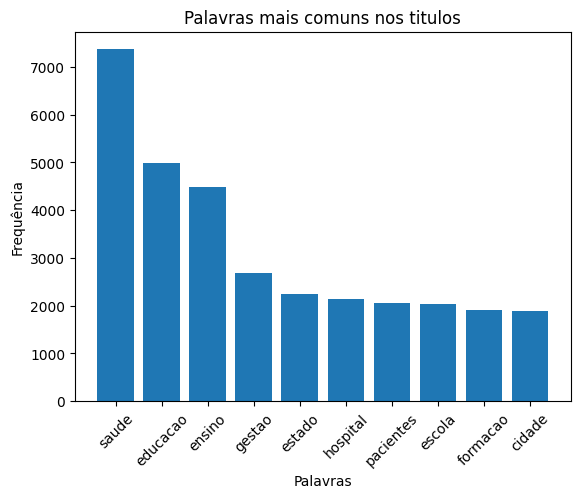

In [ ]:
# Visualizando as palavras mais comuns
words, counts = zip(*most_common_words)
plt.bar(words, counts)
plt.xlabel('Palavras')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.title('Palavras mais comuns nos titulos')
plt.show()

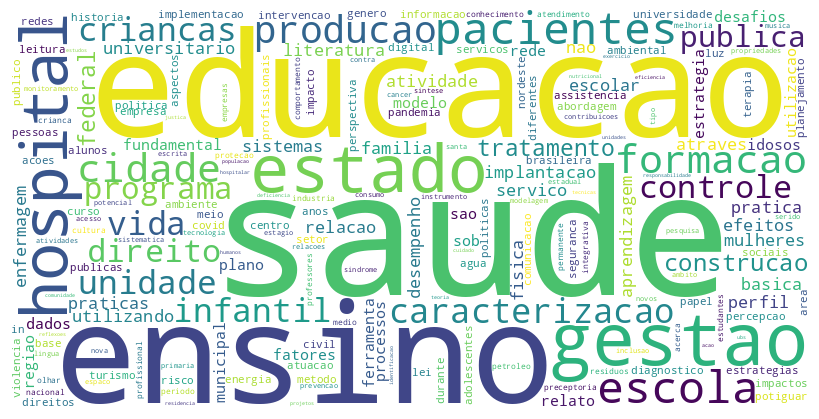

In [ ]:
# Gerando uma nuvem de palavras a partir da frequência das palavras depois de tratado
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

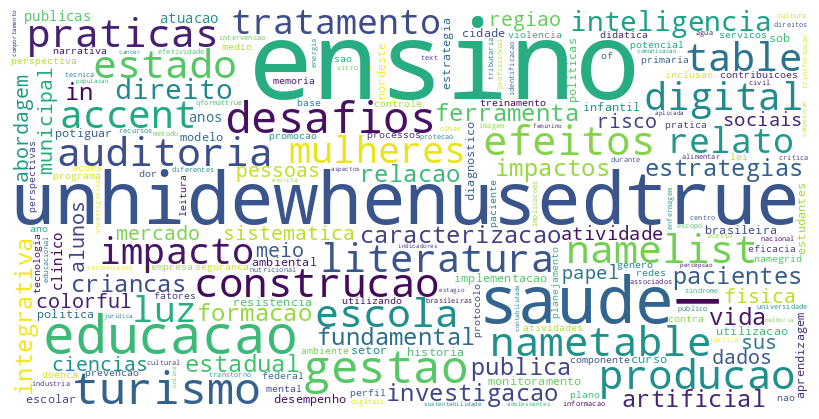

In [ ]:
# Gerando uma nuvem de palavras a partir da frequência dos tokens
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(token_freq)
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

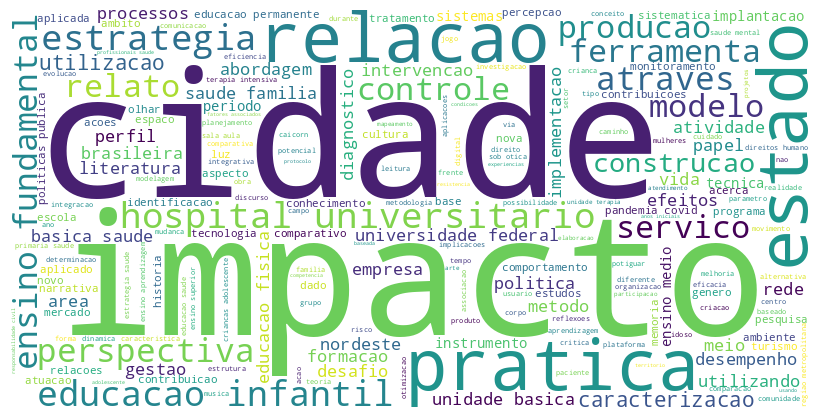

In [ ]:
# Gerando uma nuvem de palavras a partir do texto deixando o WordCloud gerar as palavras
wordcloud = WordCloud(width = 800, height = 400, background_color ='white').generate(' '.join(data['titulo3']))
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()